In [25]:
import pandas as pd
from classify import Classifier
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns


In [26]:
clf = Classifier("cfg/default.yaml")          # load task config
ckpt_path = r"output/20260616/CarQuality.Classification/mobilenet_v3_small/version_13/checkpoints/best_acc_epoch=42-val_loss=0.064-val_acc=0.985.ckpt"
results = clf.predict(
    source="datasets/dataset_2/val",
    ckpt_path=ckpt_path,
    num_classes=126,
    precision="32",
    resize=128,
)

df = pd.DataFrame(results)
df.to_csv("results.csv", index=False)

2026-06-16 15:37:12 | INFO     | classify — Classifier ready — model=mobilenet_v3_small  classes=0
2026-06-16 15:37:13 | INFO     | classify.engine.predictor — Loading model 'mobilenet_v3_small' from 'output/20260616/CarQuality.Classification/mobilenet_v3_small/version_13/checkpoints/best_acc_epoch=42-val_loss=0.064-val_acc=0.985.ckpt' on cuda…
2026-06-16 15:37:13 | INFO     | classify.models.lightning_module — Loaded pretrained weights from 'output/20260616/CarQuality.Classification/mobilenet_v3_small/version_13/checkpoints/best_acc_epoch=42-val_loss=0.064-val_acc=0.985.ckpt'.
2026-06-16 15:37:13 | INFO     | classify.engine.predictor —   1766570299807_ACURA_116.jpg  →  class=0  score=1.0000
2026-06-16 15:37:13 | INFO     | classify.engine.predictor —   1766570299811_ACURA_135.jpg  →  class=0  score=1.0000
2026-06-16 15:37:13 | INFO     | classify.engine.predictor —   1766570299821_ACURA_136.jpg  →  class=0  score=1.0000
2026-06-16 15:37:13 | INFO     | classify.engine.predictor —   1

In [27]:
import plotly.express as px

df["class_index"] = df["class_index"].astype(int)
fig = px.histogram(df, x="class_index", nbins=126, title="Distribution of Predicted Classes")
fig.show()

In [28]:
#Check the accuracy of each class predictions
# Read the labels from the Folder name

with open("output/20260616/CarQuality.Classification/mobilenet_v3_small/labels.txt", "r") as f:
    labels = f.read().splitlines()

def extract_label(file_path):
    return file_path.split("/")[-2]


df["predicted_label"] = df["class_index"].apply(lambda x: labels[x])
df["true_label"] = df["file"].apply(extract_label)
df["correct"] = df["true_label"] == df["predicted_label"]

In [29]:
df

,file,class_index,score,predicted_label,true_label,correct
0,datasets/dataset_2/val/ACURA/1766570299807_ACU...,0,1.000000,ACURA,ACURA,True
1,datasets/dataset_2/val/ACURA/1766570299811_ACU...,0,1.000000,ACURA,ACURA,True
2,datasets/dataset_2/val/ACURA/1766570299821_ACU...,0,1.000000,ACURA,ACURA,True
3,datasets/dataset_2/val/ACURA/1766570299826_ACU...,0,0.999983,ACURA,ACURA,True
4,datasets/dataset_2/val/ACURA/1766570299831_ACU...,0,1.000000,ACURA,ACURA,True
...,...,...,...,...,...,...
6937,datasets/dataset_2/val/ZOTYE/1766570487837_ZOT...,125,0.991181,ZOTYE,ZOTYE,True
6938,datasets/dataset_2/val/ZOTYE/1766570487840_ZOT...,125,1.000000,ZOTYE,ZOTYE,True
6939,datasets/dataset_2/val/ZOTYE/1766570487848_ZOT...,125,1.000000,ZOTYE,ZOTYE,True
6940,datasets/dataset_2/val/ZOTYE/1766570487852_ZOT...,125,0.907998,ZOTYE,ZOTYE,True


In [30]:
df2 = df.groupby("true_label")['correct'].mean().reset_index()
df2

,true_label,correct
0,ACURA,1.000000
1,AION,0.972727
2,ALFA ROMEO,1.000000
3,ASIA MOTOR,0.978261
4,ASTON MARTIN,0.990196
...,...,...
121,WAW,0.900000
122,WEY,0.980769
123,WULING,1.000000
124,ZEEKR,0.958904


In [31]:
df2.to_csv("class_accuracy.csv", index=False)
df.to_csv("results_with_labels.csv", index=False)

In [32]:
fig1 = px.bar(df2, x="true_label", y="correct", title="Accuracy per Class (New Model)", color="true_label", color_discrete_sequence=px.colors.qualitative.Plotly)

fig1.update_xaxes(dtick=1, type="category", tickmode="linear", automargin=True)
fig1.update_yaxes(automargin=True)


fig1.update_layout(xaxis_title="Class Label", yaxis_title="Accuracy", xaxis_tickangle=-45, width=3000, height=600)

In [33]:
from sklearn.metrics import confusion_matrix

# 1. Get sorted unique class names
classes = sorted(df['true_label'].unique())

# 2. Generate the normalized matrix
conf_mat = confusion_matrix(df['true_label'], df["predicted_label"], normalize="true")

# 3. Create the macro-view heatmap
fig = px.imshow(
    conf_mat,
    x=classes,
    y=classes,
    labels=dict(x="Predicted Label", y="True Label", color="Accuracy"),
    color_continuous_scale="Viridis",
    aspect="equal"
)

fig.update_traces(
    hovertemplate="<b>True:</b> %{y}<br><b>Predicted:</b> %{x}<br><b>Match Rate:</b> %{z:.1%}<extra></extra>"
)

fig.update_layout(
    title={
        'text': "<b>High-Dimension Confusion Matrix</b><br><sup>Evaluating 103 Distinct Classes</sup>",
        'y': 0.98,
        'x': 0.5,
        'xanchor': 'center'
    },
    width=1400,
    height=1400,
    margin=dict(t=80, b=150, l=150, r=80),
    coloraxis_showscale=True
)

fig.update_xaxes(side="bottom", tickangle=90, tickfont=dict(size=8))
fig.update_yaxes(tickfont=dict(size=8))

fig.show()

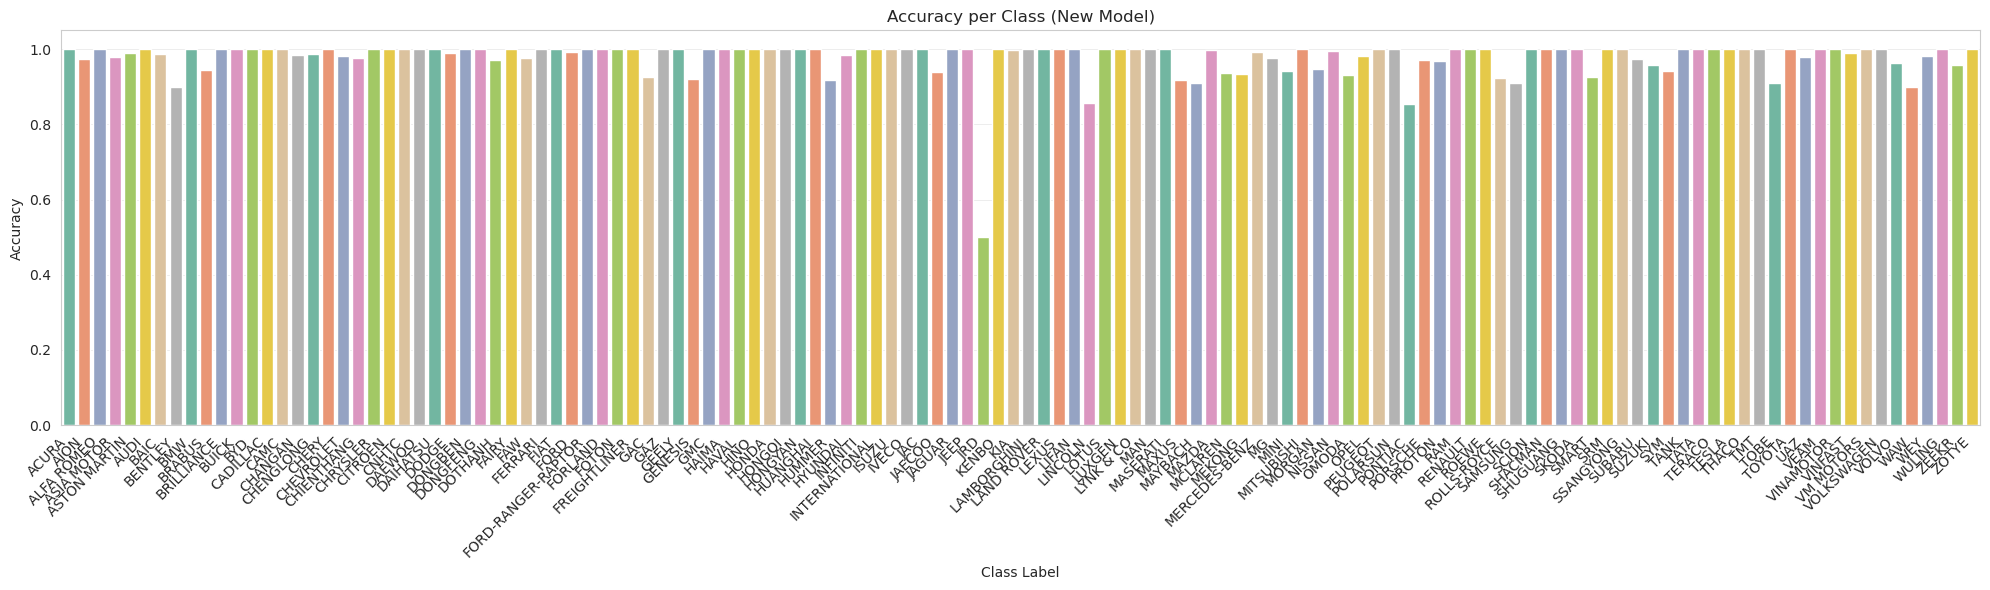

In [34]:
sns.set_style("whitegrid")

plt.figure(figsize=(20, 6))

sns.barplot(x="true_label", y="correct", hue="true_label", data=df2, palette="Set2", legend="auto")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Class Label")
plt.ylabel("Accuracy")
plt.title("Accuracy per Class (New Model)")
plt.tight_layout()
plt.show()

In [35]:
acc_new = df["correct"].mean()
print(f"Overall Accuracy of New Model: {acc_new:%}")

Overall Accuracy of New Model: 98.516278%


In [36]:
#Compared to old model

results_old = clf.predict(
    source="datasets/dataset/val",
    ckpt_path="model_20240909.ckpt",
    num_classes=98,
    precision="32",
    resize=128,
)

2026-06-16 15:39:32 | INFO     | classify.engine.predictor — Loading model 'mobilenet_v3_small' from 'model_20240909.ckpt' on cuda…
2026-06-16 15:39:32 | WARNING  | classify.engine.predictor — Safe checkpoint loading failed for 'model_20240909.ckpt'; retrying with weights_only=False. Only do this for checkpoints you trust.
2026-06-16 15:39:32 | INFO     | classify.engine.predictor — Loaded a full serialized model checkpoint directly from 'model_20240909.ckpt'.
2026-06-16 15:39:32 | INFO     | classify.engine.predictor —   1766570299807_ACURA_116.jpg  →  class=0  score=1.0000
2026-06-16 15:39:32 | INFO     | classify.engine.predictor —   1766570299811_ACURA_135.jpg  →  class=0  score=1.0000
2026-06-16 15:39:32 | INFO     | classify.engine.predictor —   1766570299821_ACURA_136.jpg  →  class=0  score=1.0000
2026-06-16 15:39:32 | INFO     | classify.engine.predictor —   1766570299826_ACURA_145.jpg  →  class=0  score=0.9974
2026-06-16 15:39:32 | INFO     | classify.engine.predictor —   1766

In [37]:
df_old = pd.DataFrame(results_old)
df_old

,file,class_index,score
0,datasets/dataset/val/ACURA/1766570299807_ACURA...,0,0.999999
1,datasets/dataset/val/ACURA/1766570299811_ACURA...,0,0.999999
2,datasets/dataset/val/ACURA/1766570299821_ACURA...,0,0.999999
3,datasets/dataset/val/ACURA/1766570299826_ACURA...,0,0.997447
4,datasets/dataset/val/ACURA/1766570299831_ACURA...,0,1.000000
...,...,...,...
4937,datasets/dataset/val/ZOTYE/1766570487837_ZOTYE...,97,0.717932
4938,datasets/dataset/val/ZOTYE/1766570487840_ZOTYE...,97,0.999999
4939,datasets/dataset/val/ZOTYE/1766570487848_ZOTYE...,97,0.907569
4940,datasets/dataset/val/ZOTYE/1766570487852_ZOTYE...,97,0.427091


In [66]:
with open("datasets/dataset/old_labels.txt", "r") as f:
    labels_old = f.read().splitlines()

df_old["predicted_label"] = df_old["class_index"].apply(lambda x: labels_old[x])
df_old["true_label"] = df_old["file"].apply(extract_label)

df_old['true_label'] = df_old['true_label'].replace("MERCEDES", "MERCEDES-BENZ")
df_old['true_label'] = df_old['true_label'].replace("ALFA_ROMEO", "ALFA ROMEO")

df_old["correct"] = df_old["true_label"] == df_old["predicted_label"]
df_old

,file,class_index,score,predicted_label,true_label,correct
0,datasets/dataset/val/ACURA/1766570299807_ACURA...,0,0.999999,ACURA,ACURA,True
1,datasets/dataset/val/ACURA/1766570299811_ACURA...,0,0.999999,ACURA,ACURA,True
2,datasets/dataset/val/ACURA/1766570299821_ACURA...,0,0.999999,ACURA,ACURA,True
3,datasets/dataset/val/ACURA/1766570299826_ACURA...,0,0.997447,ACURA,ACURA,True
4,datasets/dataset/val/ACURA/1766570299831_ACURA...,0,1.000000,ACURA,ACURA,True
...,...,...,...,...,...,...
4937,datasets/dataset/val/ZOTYE/1766570487837_ZOTYE...,97,0.717932,ZOTYE,ZOTYE,True
4938,datasets/dataset/val/ZOTYE/1766570487840_ZOTYE...,97,0.999999,ZOTYE,ZOTYE,True
4939,datasets/dataset/val/ZOTYE/1766570487848_ZOTYE...,97,0.907569,ZOTYE,ZOTYE,True
4940,datasets/dataset/val/ZOTYE/1766570487852_ZOTYE...,97,0.427091,ZOTYE,ZOTYE,True


In [67]:
fig = px.histogram(
    df_old,
    x="class_index",
    nbins=103,
    title="Distribution of Predicted Classes (Old Model)",
)
fig.show()

In [68]:
acc_old = df_old["correct"].mean()
print(f"Overall Accuracy of Old Model: {acc_old:%}")

Overall Accuracy of Old Model: 98.887090%


In [70]:
acc_old_per_class = df_old.groupby("true_label")["correct"].mean().reset_index()

fig2 = px.bar(
    acc_old_per_class,
    x="true_label",
    y="correct",
    title="Accuracy per Class (Old Model)",
    color="true_label",
    color_discrete_sequence=px.colors.qualitative.Plotly,
)

fig2.update_xaxes(dtick=1, type="category", tickmode="linear", automargin=True)
fig2.update_yaxes(automargin=True)
fig2.update_layout(
    xaxis_title="Class Label",
    yaxis_title="Accuracy",
    xaxis_tickangle=-45,
    width=3000,
    height=600,
)


In [42]:
#New model on old dataset
results_new_on_old = clf.predict(
    source="datasets/dataset/val",
    ckpt_path=ckpt_path,
    num_classes=126,
    precision="32",
    resize=128,
)



2026-06-16 15:40:44 | INFO     | classify.engine.predictor — Loading model 'mobilenet_v3_small' from 'output/20260616/CarQuality.Classification/mobilenet_v3_small/version_13/checkpoints/best_acc_epoch=42-val_loss=0.064-val_acc=0.985.ckpt' on cuda…
2026-06-16 15:40:44 | INFO     | classify.models.lightning_module — Loaded pretrained weights from 'output/20260616/CarQuality.Classification/mobilenet_v3_small/version_13/checkpoints/best_acc_epoch=42-val_loss=0.064-val_acc=0.985.ckpt'.
2026-06-16 15:40:44 | INFO     | classify.engine.predictor —   1766570299807_ACURA_116.jpg  →  class=0  score=1.0000
2026-06-16 15:40:44 | INFO     | classify.engine.predictor —   1766570299811_ACURA_135.jpg  →  class=0  score=1.0000
2026-06-16 15:40:44 | INFO     | classify.engine.predictor —   1766570299821_ACURA_136.jpg  →  class=0  score=1.0000
2026-06-16 15:40:44 | INFO     | classify.engine.predictor —   1766570299826_ACURA_145.jpg  →  class=0  score=1.0000
2026-06-16 15:40:44 | INFO     | classify.engi

In [54]:
df_new_on_old = pd.DataFrame(results_new_on_old)
df_new_on_old["predicted_label"] = df_new_on_old["class_index"].apply(lambda x: labels[x])
df_new_on_old["true_label"] = df_new_on_old["file"].apply(extract_label)

df_new_on_old['true_label'] = df_new_on_old['true_label'].replace("MERCEDES", "MERCEDES-BENZ")
df_new_on_old['true_label'] = df_new_on_old['true_label'].replace("ALFA_ROMEO", "ALFA ROMEO")

df_new_on_old["correct"] = df_new_on_old["true_label"] == df_new_on_old["predicted_label"]
acc_new_on_old = df_new_on_old["correct"].mean()
print(f"Overall Accuracy of New Model on Old Dataset: {acc_new_on_old:%}")


Overall Accuracy of New Model on Old Dataset: 99.271550%


In [55]:
df_new_on_old

,file,class_index,score,predicted_label,true_label,correct
0,datasets/dataset/val/ACURA/1766570299807_ACURA...,0,1.000000,ACURA,ACURA,True
1,datasets/dataset/val/ACURA/1766570299811_ACURA...,0,1.000000,ACURA,ACURA,True
2,datasets/dataset/val/ACURA/1766570299821_ACURA...,0,1.000000,ACURA,ACURA,True
3,datasets/dataset/val/ACURA/1766570299826_ACURA...,0,0.999983,ACURA,ACURA,True
4,datasets/dataset/val/ACURA/1766570299831_ACURA...,0,1.000000,ACURA,ACURA,True
...,...,...,...,...,...,...
4937,datasets/dataset/val/ZOTYE/1766570487837_ZOTYE...,125,0.991181,ZOTYE,ZOTYE,True
4938,datasets/dataset/val/ZOTYE/1766570487840_ZOTYE...,125,1.000000,ZOTYE,ZOTYE,True
4939,datasets/dataset/val/ZOTYE/1766570487848_ZOTYE...,125,1.000000,ZOTYE,ZOTYE,True
4940,datasets/dataset/val/ZOTYE/1766570487852_ZOTYE...,125,0.907998,ZOTYE,ZOTYE,True


In [56]:
acc_new_on_old_per_class = df_new_on_old.groupby("true_label")["correct"].mean().reset_index()

px.bar(
    acc_new_on_old_per_class,
    x="true_label",
    y="correct",
    title="Accuracy per Class (New Model on Old Dataset)",
    color="true_label",
    color_discrete_sequence=px.colors.qualitative.Plotly,
)

In [71]:
import numpy as np

merged_df = pd.merge(df2, acc_old_per_class, on="true_label", suffixes=("_new", "_old"), how="outer").fillna(0)
# Ensure acc_new_on_old_per_class is a DataFrame (it may have been overwritten as a float in a later cell)
if not isinstance(acc_new_on_old_per_class, pd.DataFrame):
    acc_new_on_old_per_class = df_new_on_old.groupby("true_label")["correct"].mean().reset_index()

merged_df = pd.merge(merged_df, acc_new_on_old_per_class, on="true_label", how="outer").fillna(0)
merged_df.columns = ["True labels", "New Model on New Dataset", "Old Model on Old Dataset", "New Model on Old Dataset"]
merged_df.to_excel(
    "accuracy_comparison_horizontal_bar.xlsx",
    index=False, )

In [72]:
merged_df

,True labels,New Model on New Dataset,Old Model on Old Dataset,New Model on Old Dataset
0,ACURA,1.000000,1.0,1.0
1,AION,0.972727,0.0,0.0
2,ALFA ROMEO,1.000000,1.0,1.0
3,ASIA MOTOR,0.978261,0.0,0.0
4,ASTON MARTIN,0.990196,0.0,0.0
...,...,...,...,...
121,WAW,0.900000,1.0,0.9
122,WEY,0.980769,0.0,0.0
123,WULING,1.000000,1.0,1.0
124,ZEEKR,0.958904,0.0,0.0


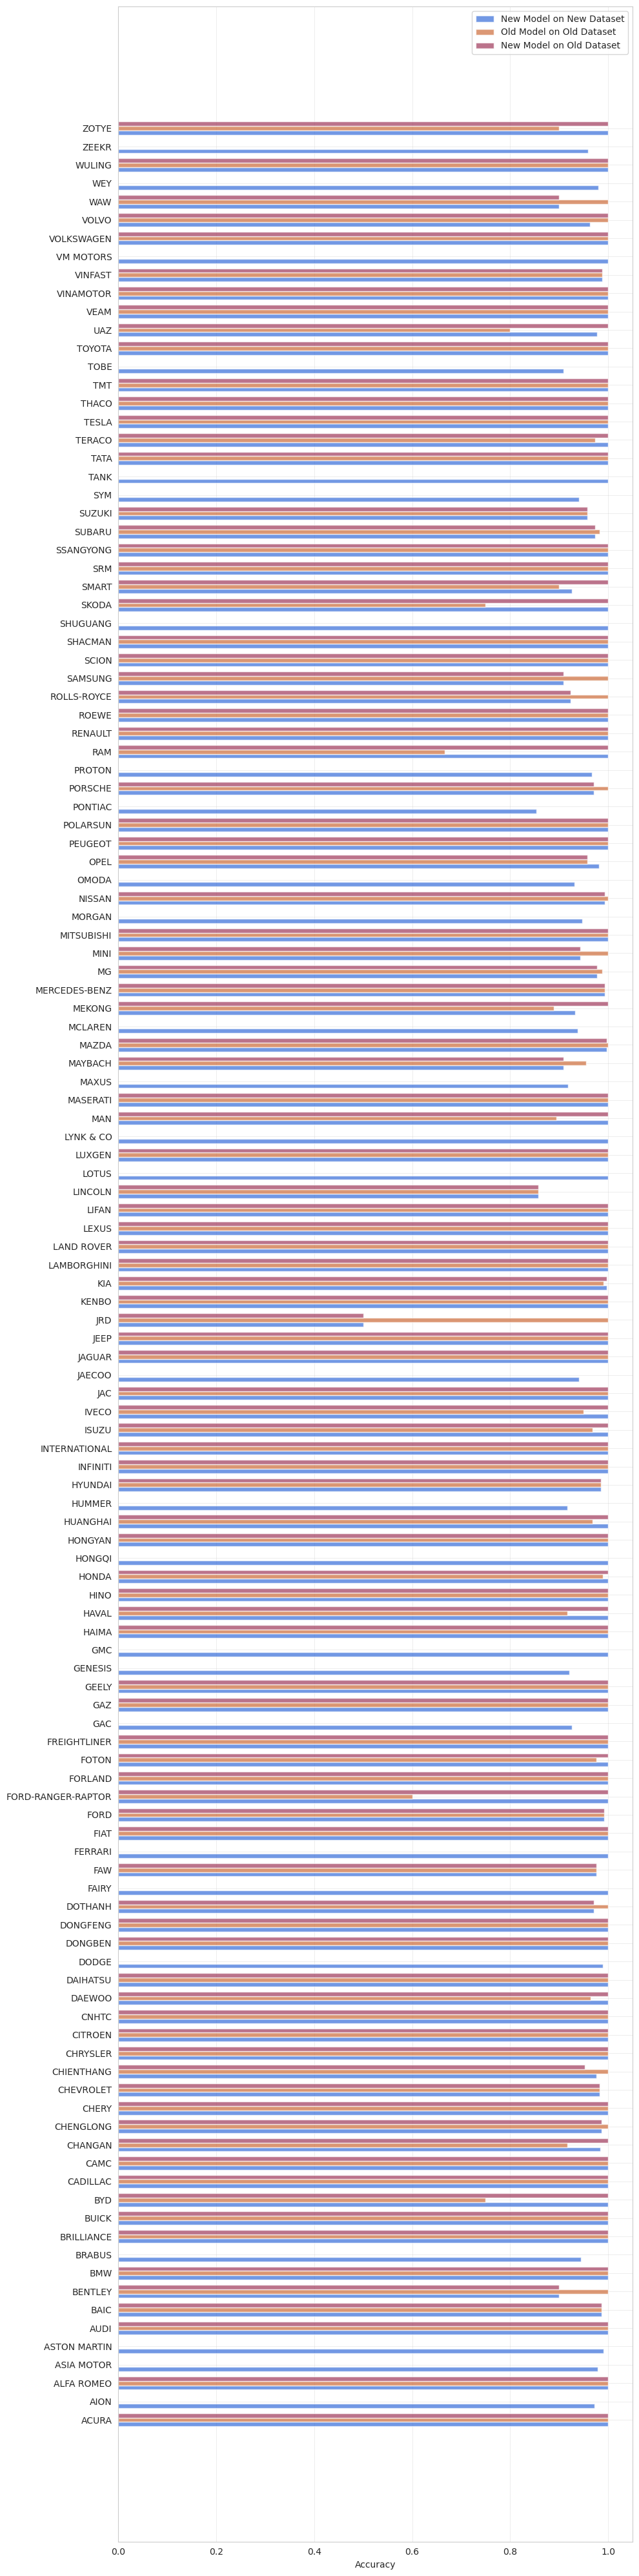

In [73]:
height = 0.24
y = np.arange(len(merged_df))
plt.figure(figsize=(10, 40))
plt.barh(y - height, merged_df["New Model on New Dataset"], height=height, label="New Model on New Dataset", alpha=0.7)
plt.barh(y, merged_df["Old Model on Old Dataset"], height=height, label="Old Model on Old Dataset", alpha=0.7)
plt.barh(y + height, merged_df["New Model on Old Dataset"], height=height, label="New Model on Old Dataset", alpha=0.7)
plt.yticks(y, merged_df["True labels"])
plt.xlabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig("accuracy_comparison_horizontal_bar.png")
plt.show()


In [75]:
acc_new_on_old_mean = df_new_on_old["correct"].mean()
print(f"Overall Accuracy of New Model on Old Dataset: {acc_new_on_old_mean:2.2%}")

acc_new = df["correct"].mean()
print(f"Overall Accuracy of New Model on New Dataset: {acc_new:2.2%}")

acc_old = df_old["correct"].mean()
print(f"Overall Accuracy of Old Model on Old Dataset: {acc_old:2.2%}")

Overall Accuracy of New Model on Old Dataset: 99.27%
Overall Accuracy of New Model on New Dataset: 98.52%
Overall Accuracy of Old Model on Old Dataset: 98.89%
